notebooks modified as a sign that your new imp was seen
              Split/Class  Count
0        data1 Train Real  12848
1        data1 Train Fake  12848
2          data1 Val Real   1606
3          data1 Val Fake   1606
4         data1 Test Real   1606
5         data1 Test Fake   1606
6        data2 Train Real    589
7        data2 Train Fake    700
8      own_extracted_real     33
9  own_extracted_aug_real    201


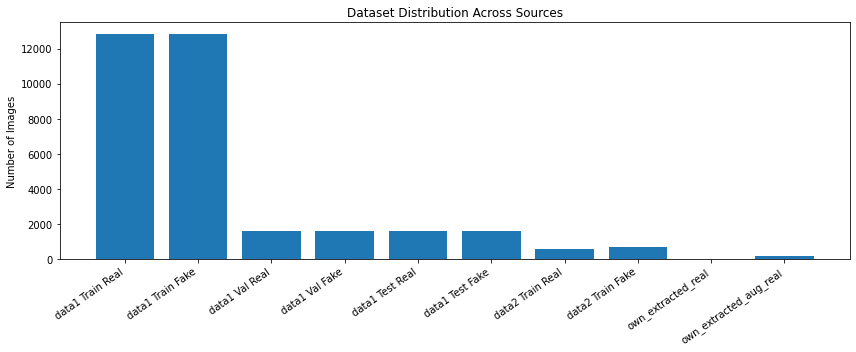

data1 - Real Samples:


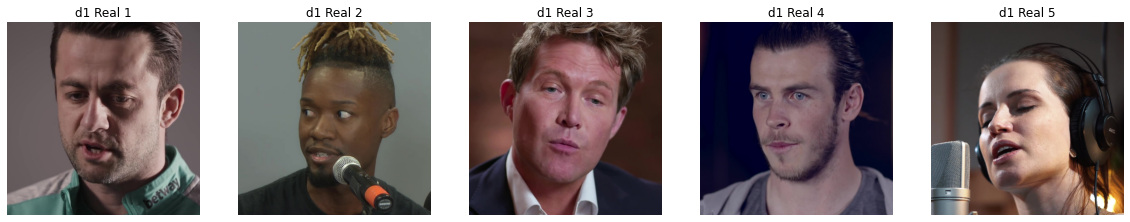

data1 - Fake Samples:


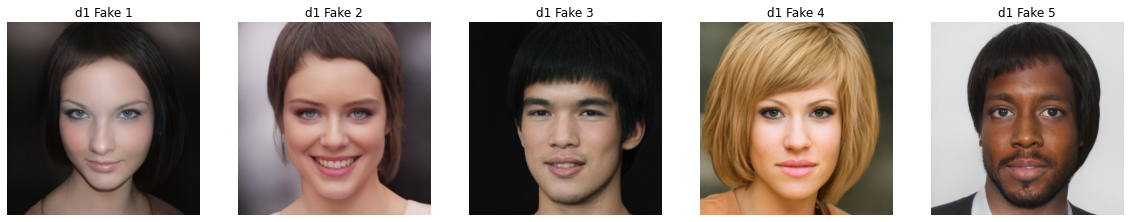

data2 - Real Samples:


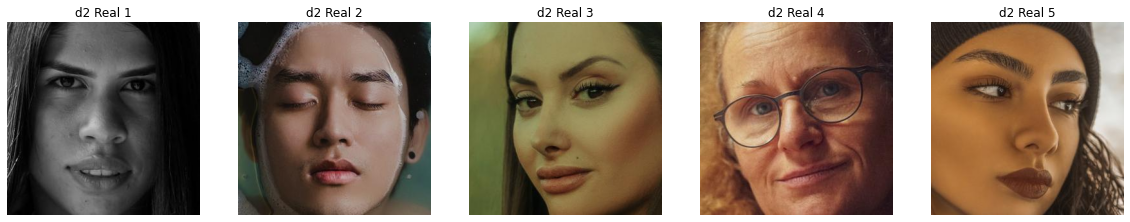

data2 - Fake Samples:


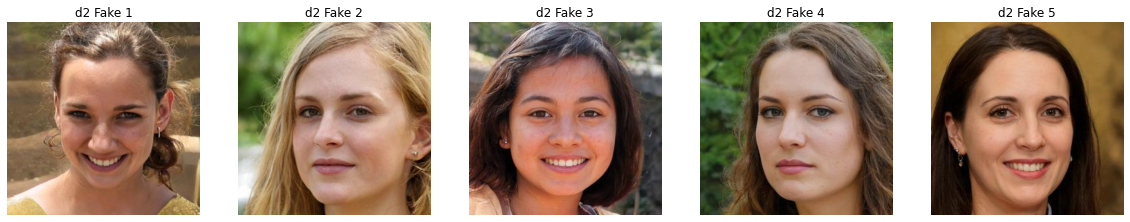

Own Extracted Real Samples:


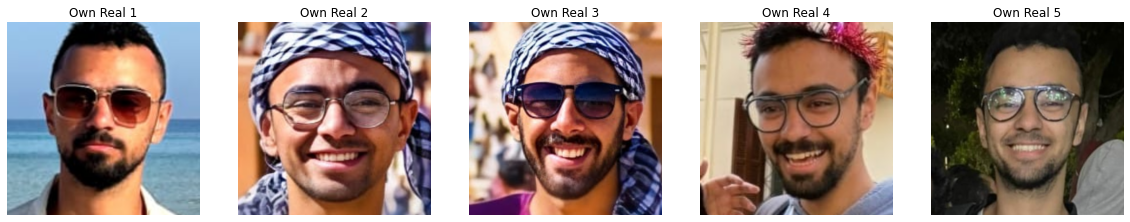

Analyzing data2_fake: 100%|██████████| 500/500 [00:02<00:00, 235.67it/s]


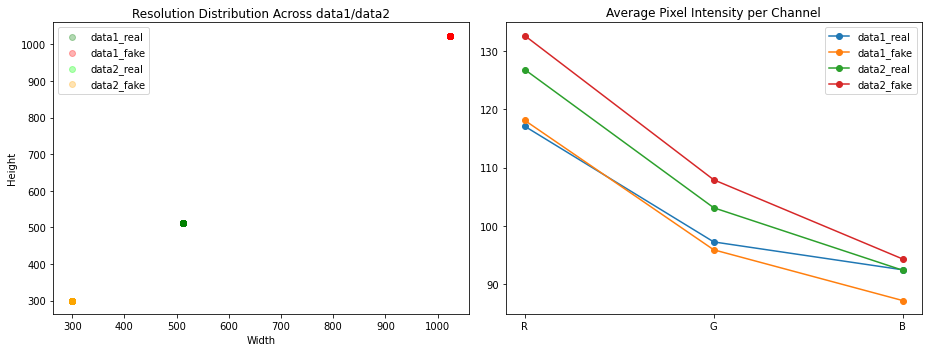

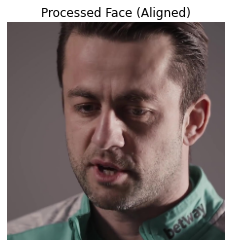

Saved 200 images to: c:\Users\youssefsaad5\Downloads\deep_fake_project\dataset\own_dataset_extracted_augmented\real


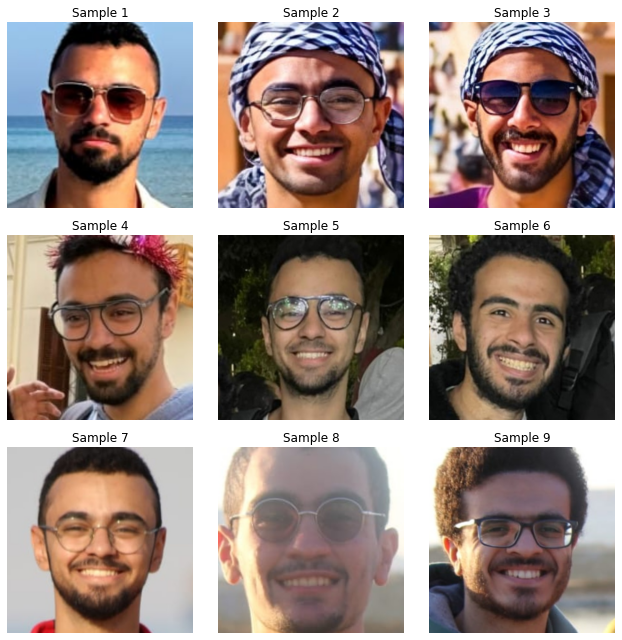

Saved preview image: c:\Users\youssefsaad5\Downloads\deep_fake_project\dataset\own_dataset_extracted_augmented\real\augmented_preview_9_samples.png


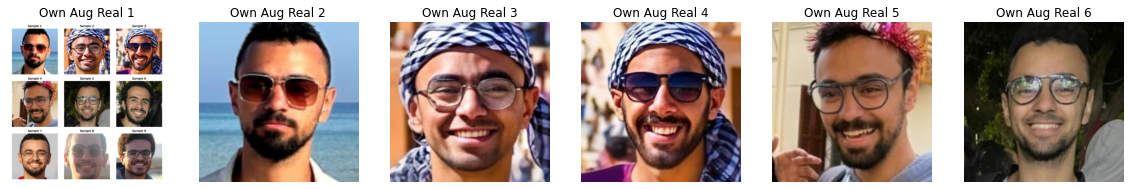

In [2]:
print("notebooks modified as a sign that your new imp was seen")
#!/usr/bin/env python
# coding: utf-8

# # Deepfake Detection System - Notebook 1
# ## Data Exploration & Preprocessing (OpenCV-based)
# 
# **Objective:**
# 1. Explore the dataset and visualize samples.
# 2. Perform bias analysis (Resolution, Color distributions).
# 3. Implement an OpenCV-based preprocessing pipeline (Face detection, alignment, normalization).
# 4. Prepare the dataset for model training.

# In[1]:


import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from collections import Counter
from PIL import Image
from torchvision import transforms
import random

# Set base paths
DATASET_PATH = r'c:\Users\youssefsaad5\Downloads\deep_fake_project\dataset'
DATA1_PATH = os.path.join(DATASET_PATH, 'data1')
DATA2_PATH = os.path.join(DATASET_PATH, 'data2')
OWN_EXTRACTED_REAL = os.path.join(DATASET_PATH, 'own_dataset_extracted', 'real')
OWN_EXTRACTED_AUG_REAL = os.path.join(DATASET_PATH, 'own_dataset_extracted_augmented', 'real')

# data1 split paths (main dataset)
TRAIN_REAL = os.path.join(DATA1_PATH, 'train', 'real')
TRAIN_FAKE = os.path.join(DATA1_PATH, 'train', 'fake')
VAL_REAL = os.path.join(DATA1_PATH, 'val', 'real')
VAL_FAKE = os.path.join(DATA1_PATH, 'val', 'fake')
TEST_REAL = os.path.join(DATA1_PATH, 'test', 'real')
TEST_FAKE = os.path.join(DATA1_PATH, 'test', 'fake')

# data2 (additional training dataset)
DATA2_REAL = os.path.join(DATA2_PATH, 'real')
DATA2_FAKE = os.path.join(DATA2_PATH, 'fake')

# ### 1. Dataset Statistics

# In[2]:


def count_files(dir_path):
    if not os.path.exists(dir_path):
        return 0
    return len([f for f in os.listdir(dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

stats = {
    'data1 Train Real': count_files(TRAIN_REAL),
    'data1 Train Fake': count_files(TRAIN_FAKE),
    'data1 Val Real': count_files(VAL_REAL),
    'data1 Val Fake': count_files(VAL_FAKE),
    'data1 Test Real': count_files(TEST_REAL),
    'data1 Test Fake': count_files(TEST_FAKE),
    'data2 Train Real': count_files(DATA2_REAL),
    'data2 Train Fake': count_files(DATA2_FAKE),
    'own_extracted_real': count_files(OWN_EXTRACTED_REAL),
    'own_extracted_aug_real': count_files(OWN_EXTRACTED_AUG_REAL),
}

df_stats = pd.DataFrame(list(stats.items()), columns=['Split/Class', 'Count'])
print(df_stats)

plt.figure(figsize=(12, 5))
plt.bar(df_stats['Split/Class'], df_stats['Count'])
plt.title('Dataset Distribution Across Sources')
plt.ylabel('Number of Images')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


# ### 2. Sample Visualization

# In[3]:


def plot_samples(path, title, count=5):
    files = glob.glob(os.path.join(path, '*'))[:count]
    if len(files) == 0:
        print(f"No files found in {path}")
        return
    plt.figure(figsize=(20, 4))
    for i, file in enumerate(files):
        img = cv2.imread(file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, len(files), i + 1)
        plt.imshow(img)
        plt.title(f"{title} {i+1}")
        plt.axis('off')
    plt.show()

print("data1 - Real Samples:")
plot_samples(TRAIN_REAL, "d1 Real")
print("data1 - Fake Samples:")
plot_samples(TRAIN_FAKE, "d1 Fake")
print("data2 - Real Samples:")
plot_samples(DATA2_REAL, "d2 Real")
print("data2 - Fake Samples:")
plot_samples(DATA2_FAKE, "d2 Fake")
print("Own Extracted Real Samples:")
plot_samples(OWN_EXTRACTED_REAL, "Own Real")


# ### 3. Bias Analysis (Resolution & Color Distribution)
# 
# We analyze if there are systemic differences in resolution or color between real and fake images that might lead to model bias.

# In[4]:


def analyze_bias(paths, labels, sample_size=500):
    data = []
    for path, label in zip(paths, labels):
        files = glob.glob(os.path.join(path, '*'))[:sample_size]
        for f in tqdm(files, desc=f"Analyzing {label}"):
            img = cv2.imread(f)
            if img is None:
                continue
            h, w, _ = img.shape
            avg_color = img.mean(axis=(0, 1))
            data.append({
                "Label": label,
                "Width": w,
                "Height": h,
                "Mean_B": avg_color[0],
                "Mean_G": avg_color[1],
                "Mean_R": avg_color[2]
            })
    return pd.DataFrame(data)

bias_df = analyze_bias(
    [TRAIN_REAL, TRAIN_FAKE, DATA2_REAL, DATA2_FAKE],
    ["data1_real", "data1_fake", "data2_real", "data2_fake"]
)

# Plotting Resolution Bias
plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
for lbl, clr in [("data1_real", "green"), ("data1_fake", "red"), ("data2_real", "lime"), ("data2_fake", "orange")]:
    sub = bias_df[bias_df['Label'] == lbl]
    plt.scatter(sub['Width'], sub['Height'], alpha=0.3, label=lbl, c=clr)
plt.title("Resolution Distribution Across data1/data2")
plt.xlabel("Width")
plt.ylabel("Height")
plt.legend()

# Plotting Color Bias
plt.subplot(1, 2, 2)
for lbl in ["data1_real", "data1_fake", "data2_real", "data2_fake"]:
    avg = bias_df[bias_df['Label'] == lbl][['Mean_R', 'Mean_G', 'Mean_B']].mean().values
    plt.plot(['R', 'G', 'B'], avg, marker='o', label=lbl)
plt.title("Average Pixel Intensity per Channel")
plt.legend()
plt.tight_layout()
plt.show()


# ### 4. OpenCV Preprocessing Pipeline
# 
# We use OpenCV's Haar Cascades for face detection. If a face isn't detected, we fall back to a center crop.

# In[ ]:


face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def preprocess_image(img_path, target_size=(224, 224), padding=0.2):
    """Detects face, crops with padding, and resizes."""
    img = cv2.imread(img_path)
    if img is None: return None
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    if len(faces) == 0:
        # Fallback if no face detected: just resize centrally
        h, w = img.shape[:2]
        side = min(h, w)
        start_x = (w - side) // 2
        start_y = (h - side) // 2
        face_img = img[start_y:start_y+side, start_x:start_x+side]
    else:
        # Pick the largest face detected
        (x, y, w, h) = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
        
        # Add padding
        pad_w = int(w * padding)
        pad_h = int(h * padding)
        
        x1 = max(0, x - pad_w)
        y1 = max(0, y - pad_h)
        x2 = min(img.shape[1], x + w + pad_w)
        y2 = min(img.shape[0], y + h + pad_h)
        
        face_img = img[y1:y2, x1:x2]
    
    # Resize to target size
    face_img = cv2.resize(face_img, target_size)
    return cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)

# Test Preprocessing
test_img = glob.glob(os.path.join(TRAIN_REAL, '*'))[0]
processed = preprocess_image(test_img)
plt.imshow(processed)
plt.title("Processed Face (Aligned)")
plt.axis('off')
plt.show()


# ### 5. Offline Augmentation for `own_dataset_extracted/real`
# 
# Goal:
# 1. Start from the 33 real images in `own_dataset_extracted/real`.
# 2. Generate and **save** augmented images to disk (not on-the-fly).
# 3. Reach **200 total images** in `own_dataset_extracted_augmented/real`.
# 4. Use this saved folder later in model training as additional `real` data.

# In[ ]:


os.makedirs(OWN_EXTRACTED_AUG_REAL, exist_ok=True)

source_files = sorted(glob.glob(os.path.join(OWN_EXTRACTED_REAL, '*')))
valid_ext = ('.png', '.jpg', '.jpeg')
source_files = [f for f in source_files if f.lower().endswith(valid_ext)]

target_total = 200
if len(source_files) == 0:
    raise RuntimeError(f"No source images found in {OWN_EXTRACTED_REAL}")

# Clean and rebuild augmented folder for reproducibility
for old_f in glob.glob(os.path.join(OWN_EXTRACTED_AUG_REAL, '*')):
    if old_f.lower().endswith(valid_ext):
        os.remove(old_f)

aug_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.7),
    transforms.RandomRotation(degrees=18),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.02),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.08)),
])

# Save originals first
save_idx = 0
for src in source_files:
    img = Image.open(src).convert('RGB')
    out_name = f"real_{save_idx:04d}.jpg"
    img.save(os.path.join(OWN_EXTRACTED_AUG_REAL, out_name), quality=95)
    save_idx += 1

# Generate augmented images until target_total
rng = random.Random(42)
while save_idx < target_total:
    src = rng.choice(source_files)
    img = Image.open(src).convert('RGB')
    aug_img = aug_tf(img)
    out_name = f"real_{save_idx:04d}.jpg"
    aug_img.save(os.path.join(OWN_EXTRACTED_AUG_REAL, out_name), quality=95)
    save_idx += 1

print(f"Saved {save_idx} images to: {OWN_EXTRACTED_AUG_REAL}")

# Save a 3x3 (9-sample) preview image in the same folder
preview_files = sorted(glob.glob(os.path.join(OWN_EXTRACTED_AUG_REAL, '*.jpg')))[:9]
if len(preview_files) == 9:
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for i, ax in enumerate(axes.flat):
        img = cv2.imread(preview_files[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"Sample {i+1}")
        ax.axis('off')
    plt.tight_layout()
    preview_path = os.path.join(OWN_EXTRACTED_AUG_REAL, 'augmented_preview_9_samples.png')
    plt.savefig(preview_path, dpi=150)
    plt.show()
    print(f"Saved preview image: {preview_path}")

# Quick visualization in notebook
plot_samples(OWN_EXTRACTED_AUG_REAL, "Own Aug Real", count=6)



In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print('--- RAW DATASET BIAS SANITY CHECK ---')
print('Training a model to predict Fake based ONLY on [Width, Height, Mean R, G, B]\n')

if 'bias_df' in locals():
    # Create binary target: 1 for fake, 0 for real
    bias_df['Target'] = bias_df['Label'].apply(lambda x: 1 if 'fake' in x else 0)
    
    # Select only the explicit resolution and color features
    X = bias_df[['Width', 'Height', 'Mean_R', 'Mean_G', 'Mean_B']]
    y = bias_df['Target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Extremely shallow tree to prevent overfitting and force simple rules
    clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    print(f'Sanity Check Accuracy on Raw Data: {acc*100:.2f}%')
    print('\nFeature Importances (How much the model relied on simple stats):')
    for feat, imp in zip(X.columns, clf.feature_importances_):
        print(f'  - {feat}: {imp*100:.1f}%')
        
    print('\n========================================================')
    if acc > 0.70:
        print('[WARNING] High Dataset Bias Detected! The raw images are highly separable using basic statistics.')
        print('This is why our preprocessing (Face Detection + 224x224 Resize) is crucial. It standardizes the resolution and removes background color leakage, forcing the CNN to learn actual facial artifacts.')
    else:
        print('[INFO] The bias level is relatively low on these basic statistics.')
else:
    print("Please run the Bias Analysis cell above to generate 'bias_df' first.")


--- RAW DATASET BIAS SANITY CHECK ---
Training a model to predict Fake based ONLY on [Width, Height, Mean R, G, B]

Sanity Check Accuracy on Raw Data: 81.75%

Feature Importances (How much the model relied on simple stats):
  - Width: 43.1%
  - Height: 45.4%
  - Mean_R: 6.0%
  - Mean_G: 2.5%
  - Mean_B: 3.0%

[WARNING] High Dataset Bias Detected! The raw images are highly separable using basic statistics.
This is why our preprocessing (Face Detection + 224x224 Resize) is crucial. It standardizes the resolution and removes background color leakage, forcing the CNN to learn actual facial artifacts.


In [4]:
!pip install --upgrade scipy scikit-learn
